# Day 02 — E-commerce Customer RFM Analysis
**Dataset:** UCI Online Retail (541,909 transactions)

**Goal:** Segment customers by Recency, Frequency and Monetary value

**Tools:** Python, Pandas, Seaborn, Matplotlib

In [1]:
# Importing Libraries

import os
os.chdir(os.path.expanduser('~/Desktop/DataAnalystJourney/day02-ecommerce-rfm'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Loading Dataset

df = pd.read_excel('data/Online Retail.xlsx')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Checking Column names and Quality

print("Columns:", df.columns.tolist())
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nDate range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
df.describe().round(2)

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate rows: 5268

Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.00,541909,541909.00,406829.00
mean,9.55,2011-07-04 13:34:57.156386048,4.61,15287.69
min,-80995.00,2010-12-01 08:26:00,-11062.06,12346.00
25%,1.00,2011-03-28 11:34:00,1.25,13953.00
50%,3.00,2011-07-19 17:17:00,2.08,15152.00
75%,10.00,2011-10-19 11:27:00,4.13,16791.00
max,80995.00,2011-12-09 12:50:00,38970.00,18287.00
std,218.08,NaN,96.76,1713.60


In [4]:
# Cleaning the Data

# Removing rows with no CustomerID, negative quantities and zero prices
df_clean = df.dropna(subset=['CustomerID'])
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]
df_clean = df_clean.drop_duplicates()

# Creating TotalPrice column
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"Rows before cleaning: {len(df)}")
print(f"Rows after cleaning:  {len(df_clean)}")
print(f"Unique customers:     {df_clean['CustomerID'].nunique()}")

Rows before cleaning: 541909
Rows after cleaning:  392692
Unique customers:     4338


In [5]:
# Calculating RFM Score

# Use day after last invoice as snapshot date
snapshot_date = df_clean['InvoiceDate'].max() + pd.DateOffset(days=1)

rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo':   'nunique',
    'TotalPrice':  'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
rfm = rfm[rfm['Monetary'] > 0]

print("RFM Table:")
print(rfm.describe().round(2))
rfm.head(10)

RFM Table:
       CustomerID  Recency  Frequency   Monetary
count     4338.00  4338.00    4338.00    4338.00
mean     15300.41    92.54       4.27    2048.69
std       1721.81   100.01       7.70    8985.23
min      12346.00     1.00       1.00       3.75
25%      13813.25    18.00       1.00     306.48
50%      15299.50    51.00       2.00     668.57
75%      16778.75   142.00       5.00    1660.60
max      18287.00   374.00     209.00  280206.02


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
5,12352.0,36,8,2506.04
6,12353.0,204,1,89.00
7,12354.0,232,1,1079.40
8,12355.0,214,1,459.40
9,12356.0,23,3,2811.43


In [6]:
# Assigning RFM Segment

# Scoring each customer 1-5 on each dimension
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  5, labels=[1,2,3,4,5])

def segment(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment, axis=1)
print(rfm['Segment'].value_counts())

Segment
Others             1416
Loyal Customers    1003
Champions           957
At Risk             643
New Customers       319
Name: count, dtype: int64


/var/folders/rf/pdjv5h395_9bcxshc8f57fs00000gn/T/ipykernel_82905/2486441399.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seg_counts.index, y=seg_counts.values, palette=colors)


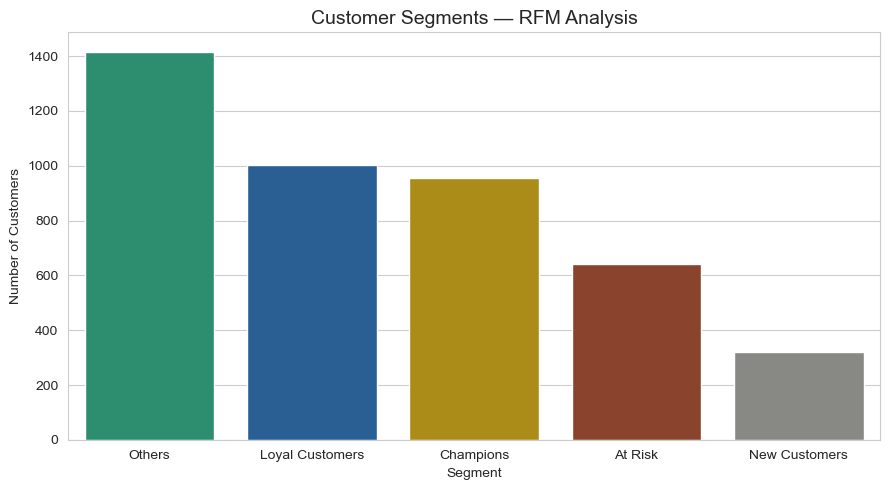

In [7]:
# Customer Segment Charts

seg_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(9, 5))
colors = ['#1D9E75','#185FA5','#C49A00','#993C1D','#888884']
sns.barplot(x=seg_counts.index, y=seg_counts.values, palette=colors)
plt.title('Customer Segments — RFM Analysis', fontsize=14)
plt.ylabel('Number of Customers')
plt.xlabel('Segment')
plt.tight_layout()
plt.savefig('charts/rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

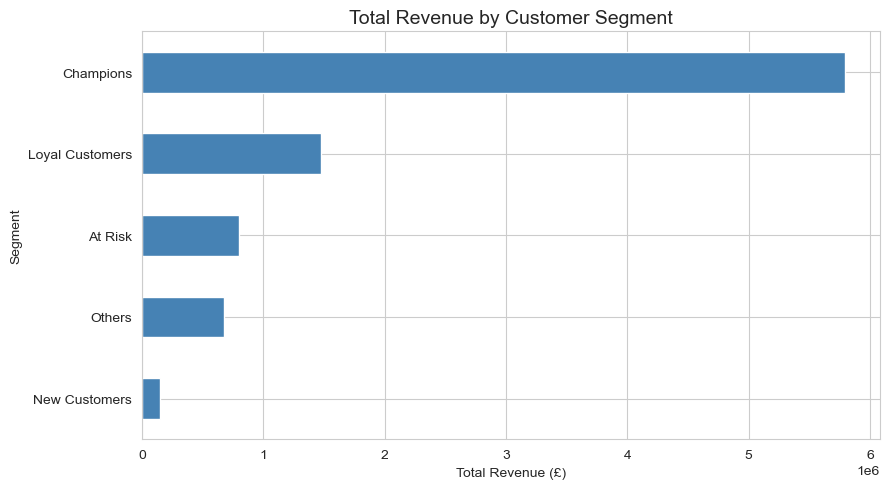

In [8]:
# Revenue by Segment

seg_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=True)

plt.figure(figsize=(9, 5))
seg_revenue.plot(kind='barh', color='steelblue')
plt.title('Total Revenue by Customer Segment', fontsize=14)
plt.xlabel('Total Revenue (£)')
plt.tight_layout()
plt.savefig('charts/revenue_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/rf/pdjv5h395_9bcxshc8f57fs00000gn/T/ipykernel_82905/444038910.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10['CustomerID'].astype(str), y=top10['Monetary'], palette='viridis')


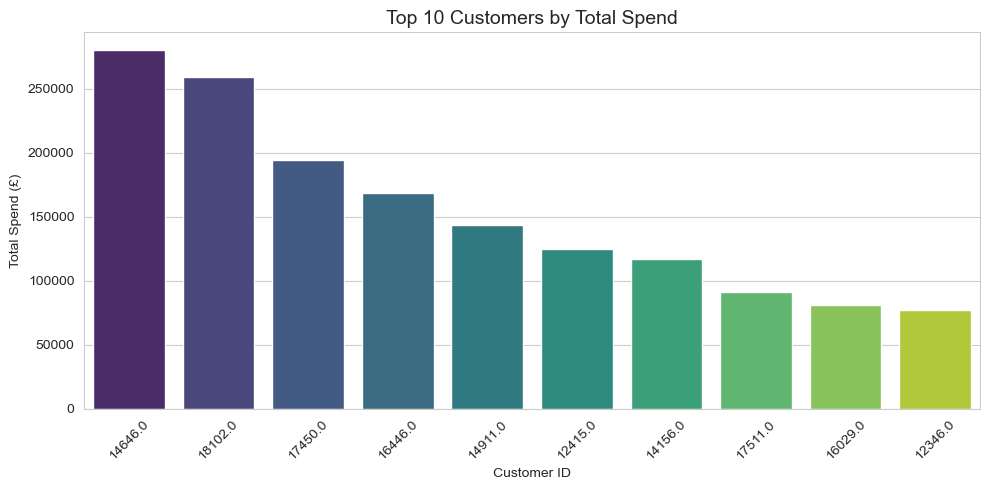

      CustomerID  Recency  Frequency   Monetary          Segment
1689     14646.0        2         73  280206.02        Champions
4201     18102.0        1         60  259657.30        Champions
3728     17450.0        8         46  194390.79        Champions
3008     16446.0        1          2  168472.50  Loyal Customers
1879     14911.0        1        201  143711.17        Champions
55       12415.0       24         21  124914.53        Champions
1333     14156.0       10         55  117210.08        Champions
3771     17511.0        3         31   91062.38        Champions
2702     16029.0       39         63   80850.84  Loyal Customers
0        12346.0      326          1   77183.60           Others


In [9]:
# Top 10 Customers by Spend

top10 = rfm.nlargest(10, 'Monetary')[['CustomerID','Recency','Frequency','Monetary','Segment']]

plt.figure(figsize=(10, 5))
sns.barplot(x=top10['CustomerID'].astype(str), y=top10['Monetary'], palette='viridis')
plt.title('Top 10 Customers by Total Spend', fontsize=14)
plt.ylabel('Total Spend (£)')
plt.xlabel('Customer ID')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('charts/top10_customers.png', dpi=150, bbox_inches='tight')
plt.show()
print(top10)

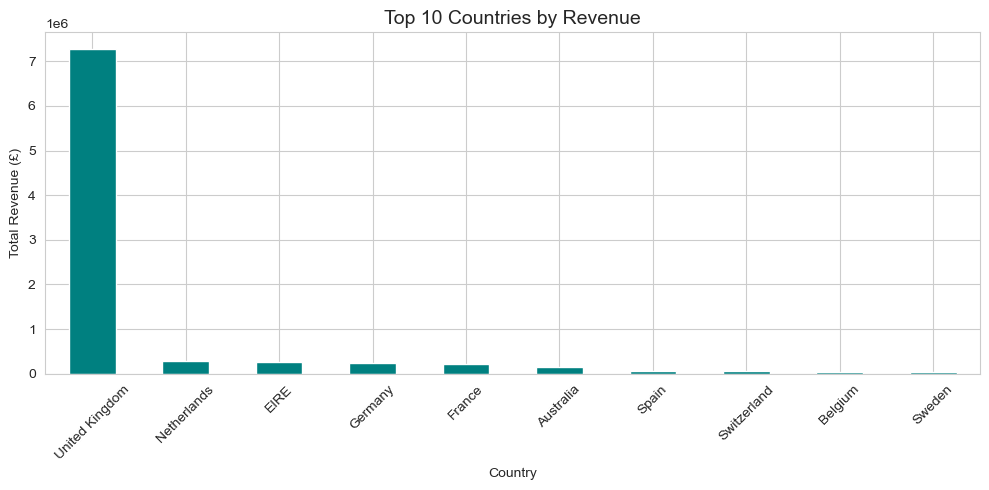

In [10]:
# Top 10 Countries by Revenue

top_countries = df_clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_countries.plot(kind='bar', color='teal')
plt.title('Top 10 Countries by Revenue', fontsize=14)
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('charts/revenue_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings

1. **Champions** are a small % of customers but drive the majority of revenue
2. **At Risk** customers — previously frequent buyers who haven't returned — need urgent retention campaigns
3. The **UK** dominates revenue — international customers represent untapped growth
4. The **top 10 customers** account for a disproportionate share of total spend (Pareto principle in action)
5. **New customers** have high recency but low frequency — retention and repeat purchase strategy needed